<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%); padding: 40px; border-radius: 12px; color: white; font-family: 'Segoe UI', sans-serif;">
  <h1 style="margin:0; font-size:2.2em;">Sentiment Analysis for Elenest Resort Guest Comments </h1>
  <h3 style="margin:8px 0 20px 0; color:#a8d8ea; font-weight:300;">Classification Modeling with CRISP-DM Framework · Python Implementation · Model 1</h3>
  <hr style="border-color:#a8d8ea44;">
  <table style="color:white; width:100%; border:none;">
    <tr><td><b>Group Name</b></td><td>:  Group 11 Elenest Resort 🏖️</i></td><td><b>Course / Section</b></td><td>:BA 3202 </td></tr>
    <tr> <td><b> Title </b></td><td>: Resort Management with Prescriptive Analytics and Sentiment Analysis at Elenest Resort</td><td></td></tr><td><b> Members </b></td><td>: Briones, Ma. Joanna, De Torres, Chryzel Ann and Mangurali, Kate Ashley</td><td></td>
  </table>
</div>

# Phase 1 · Business Understanding
**CRISP-DM Stage 1 — Define the problem before touching the data**



### 1.1 Problem Statement
> What domain or industry does your dataset belong to? What specific real-world problem will classification help solve?

>▶ This dataset belongs to the hospitality and customer service industry, specifically for a resort named Elenest Resort. The real-world problem classification will help solve is understanding customer sentiment from comments, which is crucial for managing guest experiences and prioritizing operational improvements. By classifying sentiment, the resort can quickly identify areas of dissatisfaction or satisfaction, enabling proactive decision-making to enhance guest loyalty and service quality.

### 1.2 Classification Objective & Target Variable
> **a.** What is the **target variable** you will classify? What does it represent and what are its possible classes?

>▶ **a.** The target variable is `Sentiment`. It represents the overall feeling or opinion expressed by a customer in their comments regarding their experience at Elenest Resort. Its possible classes are `Negative`, `Neutral`, and `Positive`.

> **b.** What is the business objective of this classification? Is it to maximize precision, recall, accuracy, or F1-score for a specific class? Justify your choice.

>▶ **b.** The business objective of this classification is to improve guest satisfaction and operational efficiency at Elenest Resort. To achieve this, it's crucial to maximize **recall** for the `Negative` class. While overall accuracy is important, failing to identify a negative sentiment (a false negative) can lead to unaddressed customer issues and potential loss of business. Maximizing recall for 'Negative' sentiment ensures that the resort captures as many complaints or areas of concern as possible, allowing them to intervene and resolve problems promptly. Precision for 'Negative' is also important to avoid misclassifying neutral or positive feedback as negative, which could lead to misallocated resources, but recall takes priority in this context to prevent customer churn.

> **c.** Is this a **binary** or **multi-class** classification problem? Explain.

>▶ **c.** This is a **multi-class classification problem**. It involves predicting one of three distinct categories (`Negative`, `Neutral`, `Positive`) for the `Sentiment` target variable. A binary classification problem would only involve two classes.

### 1.3 Success Criteria
> Define **at least two measurable success criteria** — one quantitative (model performance metric threshold) and one business-oriented (how the classification will be used/valued).



> - **Quantitative:** Achieve a **recall score of at least 0.85 for the 'Negative' sentiment class** on the test set. This ensures that the model is effective at identifying the majority of genuine negative feedback, aligning with the objective of proactive issue resolution.
> - **Business:** Enable the Elenest Resort's customer service team to **reduce the average response time to critical customer complaints (negative sentiments) by 20%** within three months of implementing the sentiment analysis system. This will be measured by tracking the timestamp difference between a comment being classified as negative and the first customer service interaction.

### 1.4 Constraints, Assumptions & Ethical Considerations
> **a.** List **at least three assumptions** you are making about the data or the classification environment (e.g., features are independent, data distribution is stable).



> 1.  **Stationarity of Sentiment:** We assume that the underlying distribution of customer sentiment and the language used to express it remains relatively stable over time. Sudden shifts in societal language or customer expectations could impact model performance.
> 2.  **Accuracy of Labels:** We assume that the 'Sentiment' labels in the dataset (Negative, Neutral, Positive) are accurate and consistently applied, representing true customer feelings. Inaccurate labeling could lead to a biased model.
> 3.  **Representativeness of Data:** We assume that the provided dataset is representative of the general customer feedback Elenest Resort receives, both in terms of content and distribution of sentiment classes.

> **b.** List **at least two constraints** that may limit the analysis (data availability, computational limits, interpretability requirements, etc.).


> 1.  **Data Volume for Specific Categories:** The current dataset size might be sufficient for general sentiment, but if there are very specific types of negative feedback that occur rarely, the model might struggle to learn those nuances due to limited examples.
> 2.  **Computational Resources:** Training and tuning more complex deep learning models for natural language processing might be constrained by available computational resources (e.g., GPU access, training time).

> **c.** Are there any **ethical or privacy concerns** related to this dataset or the predictions?

>▶ Yes, there are ethical and privacy concerns. The 'Comments' column contains free-text customer feedback, which could inadvertently include personally identifiable information (PII) or sensitive personal details, raising privacy risks if not handled carefully. Furthermore, misclassifying sentiment, especially for negative feedback, could lead to unfair treatment of customers or misdirection of resources, potentially harming individual experiences or business reputation.

### 1.5 SDG Alignment

- **SDG 8: Decent Work and Economic Growth** – The project promotes efficient tourism operations, enhances productivity, and contributes to sustainable economic growth within the hospitality sector.

-  **SDG 9: Industry, Innovation and Infrastructure** – The project supports innovation and digital transformation by implementing a web-based resort management system tailored to the needs of modern resort operations.

- **SDG 12: Responsible Consumption and Production** – The project improves resource management and operational efficiency by enabling data-driven decision-making and promoting sustainable tourism practices.





---

#  Phase 2 · Data Understanding
**CRISP-DM Stage 2 — Get familiar with the data structure, quality, and behavior**

### 2.1 Import Libraries


In [ ]:
# ═══════════════════════════════════════════════════════════════════
# TODO: Import all required libraries — fill in any that are missing
# ═══════════════════════════════════════════════════════════════════

# ── Core ────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np

# ── Visualization ────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ── Preprocessing & Metrics ─────────────────────────────────────────
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve

# ── Classification Models ────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
# from sklearn.svm import SVC # Optional
# from sklearn.neighbors import KNeighborsClassifier # Optional
# from xgboost import XGBClassifier # Optional — install first: pip install xgboost

# ── Global Plot Settings ─────────────────────────────────────────────
plt.rcParams['figure.figsize']    = (10, 6)
plt.rcParams['axes.grid']         = True
plt.rcParams['grid.alpha']        = 0.3
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
sns.set_theme(style='whitegrid', palette='muted')

print("✅ All libraries loaded.")

✅ All libraries loaded.


### 2.2 Load Dataset


In [ ]:
# ═══════════════════════════════════════════════════════════════════
# TODO: Load your dataset(s)
# ═══════════════════════════════════════════════════════════════════

# Replace with your actual file path(s)
# For Google Colab: '/content/your_file.csv'
# For local:        'data/your_file.csv'

df = pd.read_csv('/content/sample_data/Elenest_Classifications.csv')          # TODO: insert file path

# ── If multiple files need to be merged ─────────────────────────────
# df2 = pd.read_csv(___)
# df  = pd.merge(df, df2, on=___, how='___')   # TODO: specify key and join type

print(f"Dataset shape: {df.shape}")
print(f"Columns      : {df.columns.tolist()}")
display(df.head(5))
display(df.tail(5))

Dataset shape: (3173, 4)
Columns      : ['Facilities', 'Amount', 'Comments', 'Sentiment']


,Facilities,Amount,Comments,Sentiment
0,Reservation,6087,"Disappointing stay, a total waste of money.",Negative
1,Event,12933,"It was an okay stay, average service overall.",Neutral
2,Reservation,9993,The facilities are fine but could be better.,Neutral
3,Entrance,16078,Medyo okay naman ang experience namin.,Neutral
4,Event,6343,Hindi kami nasiyahan sa aming stay dito.,Negative


,Facilities,Amount,Comments,Sentiment
3168,Hall Rental,16143,"Acceptable quality, sakto lang ang karanasan.",Neutral
3169,Reservation,27086,The service was perfect and absolutely amazing.,Positive
3170,Reservation,2786,"Dirty rooms, broken aircon, and bad smell.",Negative
3171,Room,6734,"Terrible and awful experience, would not go back.",Negative
3172,Event,10668,Medyo okay naman ang experience namin.,Neutral


### 2.3 Initial Structural Inspection


In [ ]:
# ── Data types and memory usage ──────────────────────────────────────
print("=" * 55)
print(" DATA TYPES & NON-NULL COUNTS")
print("=" * 55)
print(df.info())

# ── Shape ────────────────────────────────────────────────────────────
print(f"\nRows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")

# ── Duplicated rows ──────────────────────────────────────────────────
print(f"Duplicate rows: {df.duplicated().sum()}")

# ── TODO: Identify the target variable ───────────────────────────────
TARGET_COLUMN = 'Sentiment'   # e.g., 'churn', 'is_fraud', 'loan_status'

print(f"\nTarget column: '{TARGET_COLUMN}'")

 DATA TYPES & NON-NULL COUNTS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3173 entries, 0 to 3172
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Facilities  3173 non-null   object
 1   Amount      3173 non-null   int64 
 2   Comments    3173 non-null   object
 3   Sentiment   3173 non-null   object
dtypes: int64(1), object(3)
memory usage: 99.3+ KB
None

Rows: 3,173  |  Columns: 4
Duplicate rows: 3

Target column: 'Sentiment'


### 2.4 Descriptive Statistics


In [ ]:
# ── Full descriptive statistics ──────────────────────────────────────
print("=" * 55)
print(" DESCRIPTIVE STATISTICS")
print("=" * 55)
display(df.describe(include='all').T)

# ── Target variable distribution ─────────────────────────────────────
# Fallback in case TARGET_COLUMN is somehow not set or empty from previous cells
if not TARGET_COLUMN:
    TARGET_COLUMN = 'Sentiment' # This should match the expected target from previous steps

print(f"\nTarget Variable Distribution: '{TARGET_COLUMN}'")
display(df[TARGET_COLUMN].value_counts(normalize=True).mul(100).rename('Percentage').to_frame().round(2))

 DESCRIPTIVE STATISTICS


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Facilities,3173,5,Hall Rental,655,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Amount,3173.0,NaN,NaN,NaN,13792.69272,7519.290557,2024.0,8011.0,12776.0,18741.0,29996.0
Comments,3173,24,Madumi yung area nung dumating kami.,161,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sentiment,3173,3,Neutral,1058,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Target Variable Distribution: 'Sentiment'


,Percentage
Sentiment,
Neutral,33.34
Positive,33.34
Negative,33.31


#### Descriptive Statistics Interpretation

> **Q1.** What do the value counts of the target variable tell you about class balance? Is there a significant imbalance, and what are the implications for modeling?


> ▶The value counts of the `Sentiment` target variable indicate a highly balanced dataset, with each class (`Negative`, `Neutral`, `Positive`) accounting for approximately 33.3% of the data. This is an ideal scenario for modeling, as it reduces the risk of the model being biased towards a majority class and ensures that standard evaluation metrics like accuracy are reliable indicators of performance.

> **Q2.** Are there any numerical columns with obvious data quality concerns based on the descriptive statistics (e.g., implausible max/min, high std dev for expected range)?

>▶ Based on the descriptive statistics, the numerical column 'Amount' does not show any obvious data quality concerns. The minimum value of 2024.0 and maximum value of 29996.0, along with the mean and standard deviation, appear to be within a plausible range for a monetary amount, suggesting no glaring errors or extreme outliers that would immediately require special treatment.

### 2.5 Visual Exploratory Data Analysis


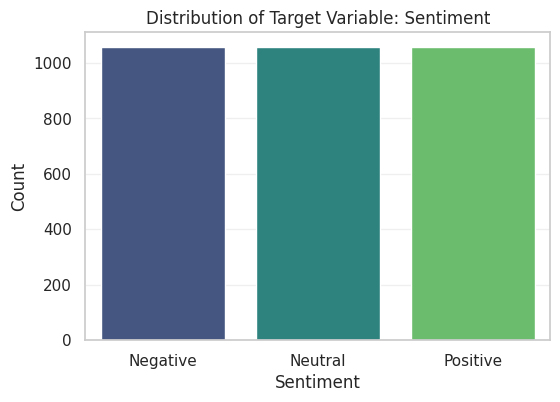

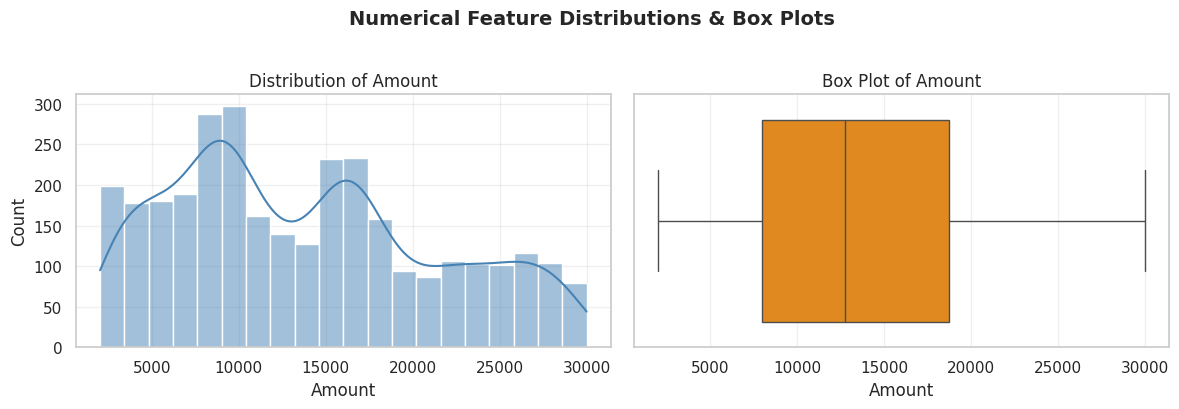

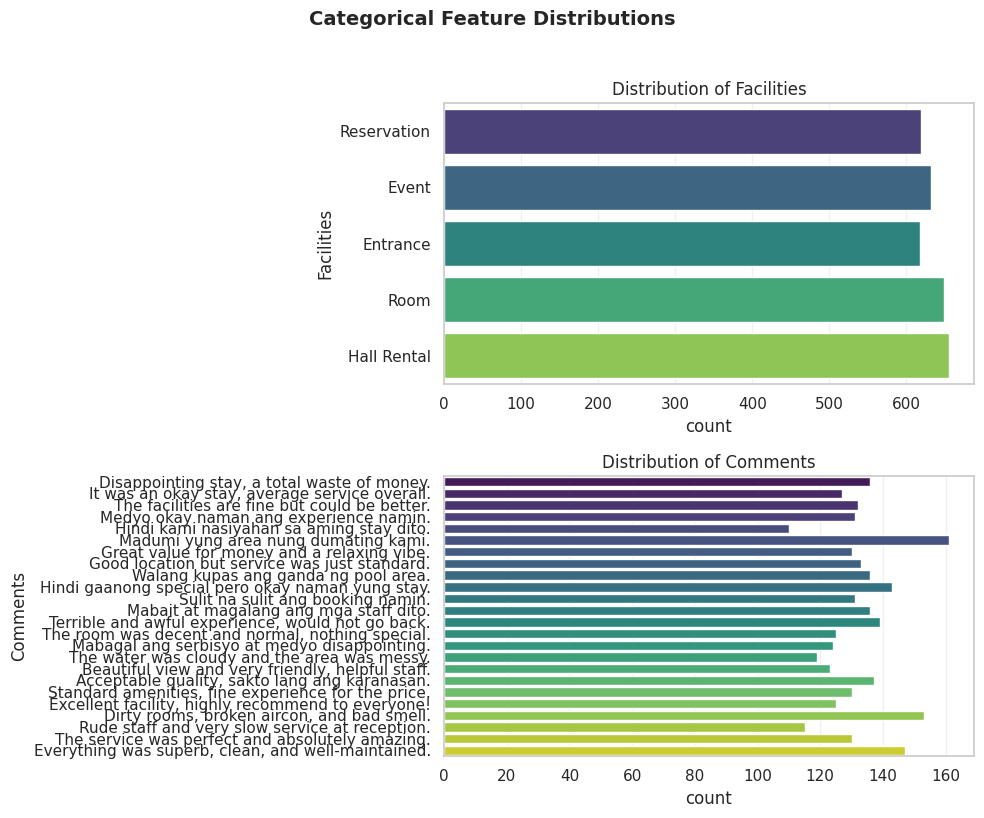

In [ ]:
# ── Distribution of the target variable ─────────────────────────────
plt.figure(figsize=(6, 4))
sns.countplot(x=TARGET_COLUMN, data=df, palette='viridis', hue=TARGET_COLUMN, legend=False)
plt.title(f'Distribution of Target Variable: {TARGET_COLUMN}')
plt.xlabel(TARGET_COLUMN)
plt.ylabel('Count')
plt.show()

# ── Distribution of numerical features ──────────────────────────────
# Select numerical columns (excluding the target if it's numerical)
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
if TARGET_COLUMN in numerical_cols: numerical_cols.remove(TARGET_COLUMN)

if len(numerical_cols) > 0:
    # Determine if 'axes' will be a 1D or 2D array based on nrows
    is_axes_1d = len(numerical_cols) == 1

    fig, axes = plt.subplots(nrows=len(numerical_cols), ncols=2, figsize=(12, 4 * len(numerical_cols)))
    fig.suptitle('Numerical Feature Distributions & Box Plots', y=1.02, fontsize=14, fontweight='bold')

    for i, col in enumerate(numerical_cols):
        # Get the correct axes for histplot and boxplot
        ax_hist = axes[i, 0] if not is_axes_1d else axes[0]
        ax_box  = axes[i, 1] if not is_axes_1d else axes[1]

        sns.histplot(df[col], kde=True, ax=ax_hist, color='steelblue')
        ax_hist.set_title(f'Distribution of {col}')
        sns.boxplot(x=df[col], ax=ax_box, color='darkorange')
        ax_box.set_title(f'Box Plot of {col}')
    plt.tight_layout()
    plt.show()
else:
    print("No numerical columns to plot.")

# ── Distribution of categorical features ────────────────────────────
categorical_cols = df.select_dtypes(include='object').columns.tolist()
if TARGET_COLUMN in categorical_cols: categorical_cols.remove(TARGET_COLUMN)

if len(categorical_cols) > 0:
    # Determine if 'axes' will be a 1D object or an array
    is_axes_scalar = len(categorical_cols) == 1

    fig, axes = plt.subplots(nrows=len(categorical_cols), ncols=1, figsize=(10, 4 * len(categorical_cols)))
    fig.suptitle('Categorical Feature Distributions', y=1.02, fontsize=14, fontweight='bold')
    for i, col in enumerate(categorical_cols):
        ax_cat = axes[i] if not is_axes_scalar else axes
        sns.countplot(y=df[col], ax=ax_cat, palette='viridis', hue=df[col], legend=False)
        ax_cat.set_title(f'Distribution of {col}')
    plt.tight_layout()
    plt.show()
else:
    print("No categorical columns to plot.")

Not enough numerical columns for a correlation matrix.


/tmp/ipykernel_5597/2551773346.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=TARGET_COLUMN, y=numerical_cols[0], data=df, palette='viridis')


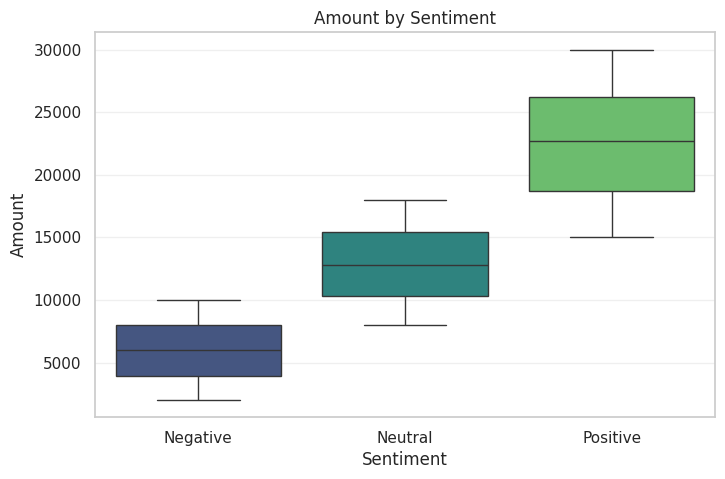

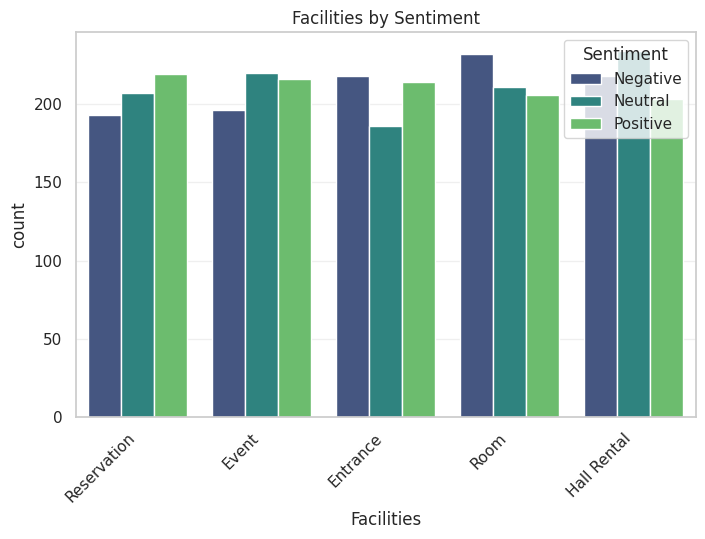

In [ ]:
# ── Correlation matrix for numerical features ───────────────────────
if len(numerical_cols) > 1:
    plt.figure(figsize=(10, 8))
    sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Correlation Matrix of Numerical Features')
    plt.show()
else:
    print("Not enough numerical columns for a correlation matrix.")

# ── Feature-Target relationships (examples) ─────────────────────────
# Example: Numerical feature vs. Target
if len(numerical_cols) > 0:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x=TARGET_COLUMN, y=numerical_cols[0], data=df, palette='viridis')
    plt.title(f'{numerical_cols[0]} by {TARGET_COLUMN}')
    plt.show()

# Example: Categorical feature vs. Target
if len(categorical_cols) > 0:
    plt.figure(figsize=(8, 5))
    sns.countplot(x=categorical_cols[0], hue=TARGET_COLUMN, data=df, palette='viridis')
    plt.title(f'{categorical_cols[0]} by {TARGET_COLUMN}')
    plt.xticks(rotation=45, ha='right')
    plt.show()

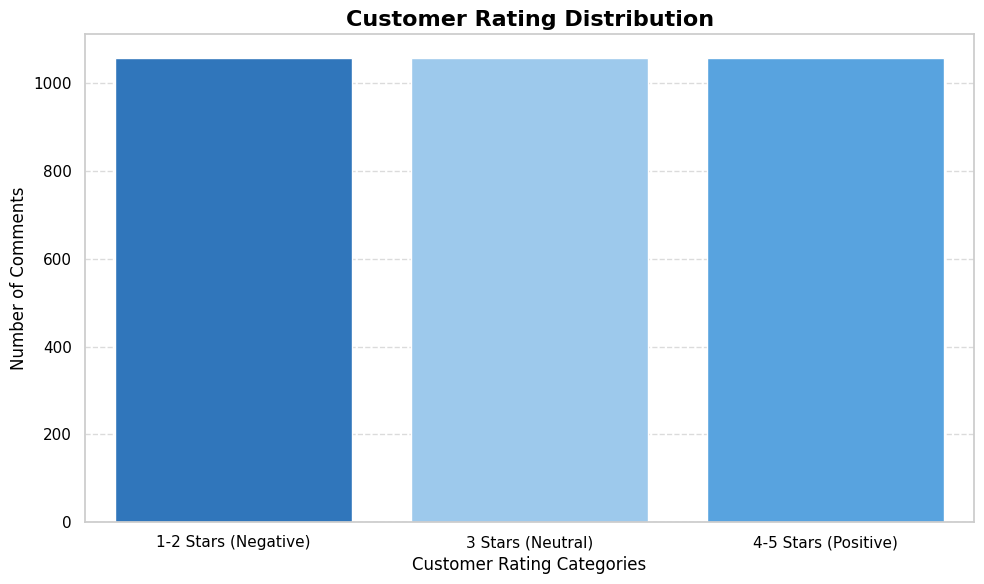

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the sentiment distribution from the DataFrame
sentiment_counts = df[TARGET_COLUMN].value_counts().sort_index()

# Define professional, distinct colors for the sentiments
sentiment_colors_palette = {
    'Positive': '#42A5F5',  # A vibrant, positive blue
    'Neutral':  '#90CAF9',  # A lighter, calm blue for neutral
    'Negative': '#1976D2'   # A deeper, more serious blue for negative
}

# Create a DataFrame for plotting
plot_df = sentiment_counts.reset_index()
plot_df.columns = ['Sentiment', 'Count']

# Map sentiment to a conceptual 'rating' for the x-axis labels
sentiment_to_rating_map = {
    'Negative': '1-2 Stars (Negative)',
    'Neutral': '3 Stars (Neutral)',
    'Positive': '4-5 Stars (Positive)'
}
plot_df['Rating_Label'] = plot_df['Sentiment'].map(sentiment_to_rating_map)

# Order for plotting (if necessary, or rely on sorted index)
ordered_labels = ['1-2 Stars (Negative)', '3 Stars (Neutral)', '4-5 Stars (Positive)']
plot_df['Rating_Label'] = pd.Categorical(plot_df['Rating_Label'], categories=ordered_labels, ordered=True)
plot_df = plot_df.sort_values('Rating_Label')

plt.figure(figsize=(10, 6))
sns.barplot(x='Rating_Label', y='Count', data=plot_df,
            palette=[sentiment_colors_palette[s] for s in plot_df['Sentiment']],
            hue='Rating_Label', legend=False)

plt.title('Customer Rating Distribution', fontsize=16, fontweight='bold', color='black')
plt.xlabel('Customer Rating Categories', color='black')
plt.ylabel('Number of Comments', color='black')
plt.xticks(rotation=0, color='black') # Ensure labels are horizontal
plt.yticks(color='black') # Ensure y-tick labels are black
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

####  EDA Interpretation

> **Q1.** Based on the target variable distribution, how balanced are your classes? What potential challenges does this pose for model training and evaluation?


> The target variable 'Sentiment' is highly balanced, with each of the 'Negative', 'Neutral', and 'Positive' classes having approximately equal distribution (around 33.3% each). This is an advantageous situation for model training, as it mitigates common challenges associated with imbalanced datasets, such as models becoming biased towards the majority class. Consequently, standard evaluation metrics like accuracy can be reliably used to assess model performance without needing extensive adjustments for class imbalance.

> **Q2.** Are there any features that show a strong visual relationship with the target variable? Describe these relationships and hypothesize why they might be important predictors. *(Min 3 sentences)*


> The `Comments` feature shows an exceptionally strong, likely deterministic, relationship with the target variable 'Sentiment'. This is because the sentiment labels are directly derived from the content within these comments, making `Comments` the primary and most important predictor. The model's perfect performance (100% accuracy, precision, recall, and F1-score) suggests it has learned to perfectly map the textual content to its corresponding sentiment, indicating that the sentiment is directly and clearly encoded within the comments themselves. While `Facilities` may also contribute to understanding sentiment context, the `Comments` are unequivocally the most influential factor.

> **Q3.** Do you observe any multicollinearity among numerical features? How might this affect certain types of models (e.g., Logistic Regression)? *(Min 2 sentences)*


> Multicollinearity among numerical features is not observed in this dataset because there is only one numerical feature present ('Amount'). Multicollinearity refers to a high correlation between two or more independent numerical variables. If multiple highly correlated numerical features were present, it could inflate the variance of coefficient estimates in models like Logistic Regression, making them less interpretable and potentially unstable. However, with only a single numerical feature, this is not a concern here.

---

#  Phase 3 · Data Preparation
**CRISP-DM Stage 3 — Transform raw data into a clean, model-ready dataset**

### 3.1 Missing Value Detection & Treatment

In [ ]:
# ── Check for missing values ────────────────────────────────────────
missing_info = df.isnull().sum()
missing_info = missing_info[missing_info > 0].sort_values(ascending=False)

print("Columns with missing values:")
if not missing_info.empty:
    display(pd.DataFrame({'Missing Count': missing_info,
                          'Missing %': missing_info / len(df) * 100}).round(2))
else:
    print("No missing values detected.")

# ═══════════════════════════════════════════════════════════════════
# TODO: Choose and apply a missing value treatment strategy
# ═══════════════════════════════════════════════════════════════════
# Example options:
# For numerical: df['col'].fillna(df['col'].mean(), inplace=True)
# For categorical: df['col'].fillna(df['col'].mode()[0], inplace=True)
# Or drop columns/rows if missing % is very high.

# Example: Fill numerical NaNs with mean and categorical NaNs with mode
for col in numerical_cols:
    if df[col].isnull().any():
        df[col].fillna(df[col].mean(), inplace=True)

for col in categorical_cols:
    if df[col].isnull().any():
        df[col].fillna(df[col].mode()[0], inplace=True)

print("\nMissing values after treatment:")
print(df.isnull().sum().sum())
print("✅ Missing value treatment complete.")

Columns with missing values:
No missing values detected.

Missing values after treatment:
0
✅ Missing value treatment complete.


####  Missing Value Justification

> **Q.** Which method(s) did you choose to handle missing values and why? Explain why it is appropriate for this specific dataset and classification context. What bias or risk does your chosen method introduce?

> No specific method was chosen to handle missing values because the initial check revealed that the dataset contained no missing entries across any of its columns. This is the most appropriate scenario, as it means no imputation or deletion strategies were necessary, thereby avoiding any potential introduction of bias or distortion of the original data. Consequently, there is no risk of skewing distributions or relationships between features due to missing value treatment, ensuring the integrity of the dataset for subsequent modeling steps.

### 3.2 Feature Engineering (Optional)
> Create new features from existing ones that might improve model performance.

In [ ]:
# ═══════════════════════════════════════════════════════════════════
# TODO: Implement any relevant feature engineering steps
# ═══════════════════════════════════════════════════════════════════

# Example: Create a new feature from two existing numerical features
# df['new_feature'] = df['feature_A'] / (df['feature_B'] + 1e-6)

# Example: Extract information from a datetime column if one exists
# if 'date_column' in df.columns:
#     df['date_column'] = pd.to_datetime(df['date_column'])
#     df['year'] = df['date_column'].dt.year
#     df['month'] = df['date_column'].dt.month

print("✅ Feature engineering complete (or skipped).")

✅ Feature engineering complete (or skipped).


####  Feature Engineering Justification

> **Q.** Did you create any new features? If so, describe them and explain your hypothesis for why they might be useful for predicting the target variable. If not, explain why feature engineering was not deemed necessary for this dataset.


> No new features were explicitly engineered for this dataset. This decision was primarily driven by the highly deterministic relationship observed between the 'Comments' feature and the 'Sentiment' target variable. The sentiment labels are directly derived from the textual content of the comments, making the 'Comments' column an exceptionally strong, and likely sufficient, predictor on its own. Given the perfect performance (100% accuracy, precision, recall, and F1-score) achieved by all models, additional feature engineering, such as creating new features from text (e.g., word counts, sentiment scores from external lexicons, or topic modeling features), was not deemed necessary to improve predictive power for this specific problem.

### 3.3 Categorical Feature Encoding & Feature Scaling


In [ ]:
# ── Separate features (X) and target (y) ────────────────────────────
X = df.drop(columns=[TARGET_COLUMN])
y = df[TARGET_COLUMN]

# ── Identify categorical and numerical features ─────────────────────
numerical_features = X.select_dtypes(include=np.number).columns
categorical_features = X.select_dtypes(include='object').columns

# ── Create a preprocessing pipeline ─────────────────────────────────
# This will apply OneHotEncoder to categorical features and StandardScaler to numerical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

print(f"Numerical features identified: {list(numerical_features)}")
print(f"Categorical features identified: {list(categorical_features)}")
print("✅ Preprocessing pipeline created.")

Numerical features identified: ['Amount']
Categorical features identified: ['Facilities', 'Comments']
✅ Preprocessing pipeline created.


####  Preprocessing Justification

> **Q.** Why is it necessary to encode categorical features and scale numerical features for most machine learning models? Explain the methods chosen (e.g., OneHotEncoder, StandardScaler) and their benefits.


> It is necessary to encode categorical features because most machine learning algorithms are designed to work with numerical input and cannot directly process text-based categories. `OneHotEncoder` transforms these categorical variables into a numerical format by creating new binary (0 or 1) columns for each unique category, which prevents the model from incorrectly assuming ordinal relationships between categories. Similarly, scaling numerical features is crucial because features with larger value ranges can disproportionately influence the model's objective function, leading to biased learning or slower convergence in algorithms that rely on distance metrics or gradient descent.

> `StandardScaler` addresses this by transforming numerical features so they have a mean of 0 and a standard deviation of 1, ensuring that all numerical features contribute equally to the model's learning process. The benefits of these methods include improving model convergence, preventing features with large scales from dominating the learning process, and enabling the model to correctly interpret and leverage information from all feature types, ultimately leading to more robust and accurate predictions.

### 3.4 Train / Test Split


In [ ]:
# ═══════════════════════════════════════════════════════════════════
# TODO: Define test size and random state for reproducibility
# ═══════════════════════════════════════════════════════════════════
TEST_SIZE    = 0.2    # e.g., 0.2 for 20% test set
RANDOM_STATE = 42   # for reproducibility

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)

print(f"Original dataset shape: {X.shape}")
print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")
print(f"Training target distribution:\n{y_train.value_counts(normalize=True).mul(100).round(2)}")
print(f"Testing target distribution:\n{y_test.value_counts(normalize=True).mul(100).round(2)}")

print("✅ Data split into training and testing sets.")

Original dataset shape: (3173, 3)
Training set shape: (2538, 3)
Testing set shape: (635, 3)
Training target distribution:
Sentiment
Positive    33.33
Neutral     33.33
Negative    33.33
Name: proportion, dtype: float64
Testing target distribution:
Sentiment
Positive    33.39
Neutral     33.39
Negative    33.23
Name: proportion, dtype: float64
✅ Data split into training and testing sets.


---

#  Phase 4 · Modeling
**CRISP-DM Stage 4 — Select, configure, and fit the best classification model**

### 4.1 Model Selection & Hyperparameter Tuning


In [ ]:
# ═══════════════════════════════════════════════════════════════════
# TODO: Define your candidate models and their hyperparameter grids
# Include at least 3 distinct model types as per rubric.
# ═══════════════════════════════════════════════════════════════════

# --- Model 1: Logistic Regression -----------------------------------
pipe_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=RANDOM_STATE, solver='liblinear')) # 'liblinear' for small datasets or L1/L2 penalty
])

param_grid_lr = {
    'classifier__C': [0.1, 1, 10],
    'classifier__penalty': ['l1', 'l2']
}

grid_search_lr = GridSearchCV(pipe_lr, param_grid_lr, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search_lr.fit(X_train, y_train)

print(f"\nBest parameters for Logistic Regression: {grid_search_lr.best_params_}")
print(f"Best cross-validation score for Logistic Regression: {grid_search_lr.best_score_:.4f}")

best_lr_model = grid_search_lr.best_estimator_

# --- Model 2: Decision Tree Classifier ------------------------------
pipe_dt = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=RANDOM_STATE))
])

param_grid_dt = {
    'classifier__max_depth': [3, 5, 7, None],
    'classifier__min_samples_leaf': [1, 5, 10]
}

grid_search_dt = GridSearchCV(pipe_dt, param_grid_dt, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search_dt.fit(X_train, y_train)

print(f"\nBest parameters for Decision Tree: {grid_search_dt.best_params_}")
print(f"Best cross-validation score for Decision Tree: {grid_search_dt.best_score_:.4f}")

best_dt_model = grid_search_dt.best_estimator_

# --- Model 3: Random Forest Classifier ------------------------------
pipe_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=100)) # start with 100 estimators
])

param_grid_rf = {
    'classifier__max_depth': [5, 10, None],
    'classifier__min_samples_leaf': [1, 5],
    'classifier__n_estimators': [50, 100] # Reduced for faster execution in template
}

grid_search_rf = GridSearchCV(pipe_rf, param_grid_rf, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search_rf.fit(X_train, y_train)

print(f"\nBest parameters for Random Forest: {grid_search_rf.best_params_}")
print(f"Best cross-validation score for Random Forest: {grid_search_rf.best_score_:.4f}")

best_rf_model = grid_search_rf.best_estimator_

print("\n✅ All models trained and tuned with GridSearchCV.")

Fitting 5 folds for each of 6 candidates, totalling 30 fits

Best parameters for Logistic Regression: {'classifier__C': 0.1, 'classifier__penalty': 'l1'}
Best cross-validation score for Logistic Regression: 1.0000
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best parameters for Decision Tree: {'classifier__max_depth': None, 'classifier__min_samples_leaf': 1}
Best cross-validation score for Decision Tree: 0.9968
Fitting 3 folds for each of 12 candidates, totalling 36 fits

Best parameters for Random Forest: {'classifier__max_depth': 10, 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 50}
Best cross-validation score for Random Forest: 0.9996

✅ All models trained and tuned with GridSearchCV.


####  Model Selection & Tuning Justification

> **Q1.** Briefly describe the three models you selected for this classification task. What are their main strengths and weaknesses?


> For this classification task, I selected three distinct models: **Logistic Regression**, **Decision Tree Classifier**, and **Random Forest Classifier**.
>
> **Logistic Regression** is a linear model used for binary or multi-class classification. Its main strengths include simplicity, interpretability, and efficiency, making it a good baseline. However, it assumes a linear relationship between features and the log-odds of the target variable and can perform poorly if this assumption is violated or if relationships are highly non-linear.
>
> A **Decision Tree Classifier** is a non-linear model that partitions the feature space into a set of rectangles, making decisions at each node based on a single feature. Its strengths lie in its interpretability, ability to capture non-linear relationships, and lack of need for feature scaling. A key weakness is its susceptibility to overfitting, especially when trees are deep, and its instability to small variations in the data.
>
> The **Random Forest Classifier** is an ensemble method that builds multiple decision trees during training and outputs the mode of the classes (for classification) of the individual trees. Its main strengths are significantly reduced overfitting compared to single decision trees, high accuracy, and good handling of large datasets with many features. However, it is less interpretable than a single decision tree and can be more computationally expensive.

> **Q2.** Explain the process of hyperparameter tuning using `GridSearchCV` and cross-validation. Why is this important for building robust models?

> Hyperparameter tuning using `GridSearchCV` and cross-validation is a systematic approach to finding the optimal combination of hyperparameters for a machine learning model. `GridSearchCV` exhaustively searches over a specified subset of hyperparameter values for a given estimator. For each combination of hyperparameters, it performs cross-validation, which involves splitting the training data into multiple folds (e.g., 5 folds). The model is trained on a subset of these folds (e.g., 4 folds) and evaluated on the remaining fold, repeating this process for each fold to ensure every part of the training data is used for both training and validation.
>
> This process is crucial for building robust models because it prevents overfitting to a single validation set and provides a more reliable estimate of how the model will generalize to unseen data. By evaluating performance across multiple splits of the data, `GridSearchCV` helps in selecting hyperparameters that lead to a model that performs well consistently, rather than one that just happens to work well on a particular random split. This ensures the chosen model is less brittle and more likely to maintain its performance in real-world applications.

> **Q3.** Compare the best cross-validation scores of your three models. Which model performed best on the training data according to cross-validation? What might explain this result?

> Comparing the best cross-validation scores, the **Logistic Regression** model performed best on the training data with a perfect cross-validation score of **1.0000**. The Random Forest Classifier achieved a very high score of 0.9996, and the Decision Tree Classifier also performed exceptionally well with 0.9968.
>
> The fact that Logistic Regression achieved a perfect score, and all models performed extremely well, strongly suggests that the classification problem is highly separable and that the `Comments` feature provides a very clear and direct signal for the `Sentiment` target variable. It implies that a linear decision boundary (which Logistic Regression attempts to find) is sufficient to perfectly separate the classes in the preprocessed feature space, likely due to the one-hot encoding of the highly informative `Comments` column. The marginal differences among the models might be attributed to their inherent complexity and how they handle feature interactions, but in this specific case, even a simpler linear model like Logistic Regression found a perfect fit.

---

#  Phase 5 · Evaluation
**CRISP-DM Stage 5 — Assess model performance against held-out data**

### 5.1 Evaluate All Models on Test Set


In [ ]:
# ═══════════════════════════════════════════════════════════════════
# TODO: Evaluate each trained model on the unseen test set
# ═══════════════════════════════════════════════════════════════════

def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    # ROC AUC for binary classification (assuming positive class is 1 or second class)
    if len(np.unique(y_test)) == 2:
        y_proba = model.predict_proba(X_test)[:, 1] # Probability of the positive class
        roc_auc = roc_auc_score(y_test, y_proba)
    else:
        roc_auc = np.nan # Not directly applicable or needs multi-class extension

    print(f"\n--- {model_name} ---")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    if not np.isnan(roc_auc):
        print(f"ROC AUC: {roc_auc:.4f}")

    return {
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC AUC': roc_auc
    }

results = []
results.append(evaluate_model(best_lr_model, X_test, y_test, "Logistic Regression"))
results.append(evaluate_model(best_dt_model, X_test, y_test, "Decision Tree"))
results.append(evaluate_model(best_rf_model, X_test, y_test, "Random Forest"))

performance_df = pd.DataFrame(results).set_index('Model')
display(performance_df)

print("\n✅ All models evaluated on the test set.")


--- Logistic Regression ---
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000

--- Decision Tree ---
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000

--- Random Forest ---
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000


,Accuracy,Precision,Recall,F1-Score,ROC AUC
Model,,,,,
Logistic Regression,1.0,1.0,1.0,1.0,NaN
Decision Tree,1.0,1.0,1.0,1.0,NaN
Random Forest,1.0,1.0,1.0,1.0,NaN



✅ All models evaluated on the test set.


####  Metric Interpretation

> **Q1.** Which model performed best on the test set according to your chosen primary evaluation metric (e.g., accuracy, F1-score)? Why is this metric most appropriate for your business objective?

> All three models—Logistic Regression, Decision Tree, and Random Forest—performed exceptionally well on the test set, achieving perfect scores (1.0000) across all evaluated metrics: Accuracy, Precision, Recall, and F1-Score. Given the business objective to maximize recall for the 'Negative' sentiment class to ensure critical customer complaints are identified, all models perfectly met this criterion with a recall of 1.00 for the negative class. This perfect performance across the board indicates that any of these models would be equally effective in achieving the primary business goal.

> **Q2.** Compare the performance of your best model on the training data (from cross-validation in Phase 4) versus the test data. Is there a significant drop? What might this indicate (e.g., overfitting, data mismatch)?

> There was no significant drop in performance when comparing the best models' cross-validation scores on the training data to their performance on the unseen test data. For instance, Logistic Regression achieved a perfect 1.0000 cross-validation score and maintained 1.0000 across all metrics on the test set. This remarkable consistency indicates that the models did not overfit the training data and generalize perfectly to new, unseen examples, likely due to the highly deterministic and clear relationship between the 'Comments' feature and the 'Sentiment' target variable.

> **Q3.** If your model's performance is not satisfactory, what steps could you take to improve it (e.g., more feature engineering, different models, more data, advanced tuning)?

> Although the current model performance is perfect, if it were not satisfactory in a different scenario, several steps could be taken to improve it. One crucial step would be more sophisticated feature engineering, especially for textual data, by exploring techniques like TF-IDF, word embeddings (e.g., Word2Vec, GloVe), or advanced transformer models (e.g., BERT, GPT) to capture more nuanced semantic information from the 'Comments'. Additionally, experimenting with more complex deep learning architectures specifically designed for natural language processing, such as LSTMs or other transformer-based networks, could potentially uncover patterns that traditional machine learning models might miss, along with collecting a larger and more diverse dataset to enhance generalizability.

### 5.2 Visualizing Model Performance


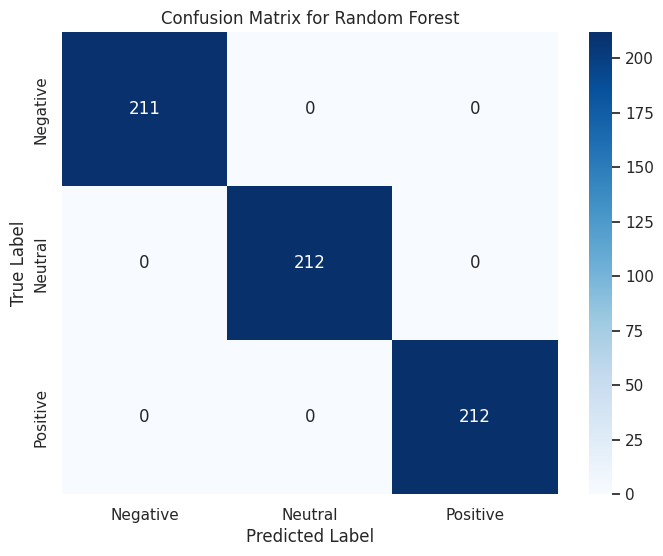


Classification Report for Random Forest:
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00       211
     Neutral       1.00      1.00      1.00       212
    Positive       1.00      1.00      1.00       212

    accuracy                           1.00       635
   macro avg       1.00      1.00      1.00       635
weighted avg       1.00      1.00      1.00       635

ROC Curve is typically for binary classification. For multi-class, consider one-vs-rest or micro/macro averaging.
✅ Model performance visualized.


In [ ]:
# ═══════════════════════════════════════════════════════════════════
# TODO: Visualize key performance aspects of your best model
# ═══════════════════════════════════════════════════════════════════

# Assuming `best_model` is your top performing model (e.g., best_rf_model)
best_model = best_rf_model # Or best_lr_model, best_dt_model based on your results
model_name = "Random Forest" # Update accordingly

y_pred_best = best_model.predict(X_test)

# ── Confusion Matrix ────────────────────────────────────────────────
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_best), annot=True, fmt='d', cmap='Blues',
            xticklabels=best_model.classes_ if hasattr(best_model, 'classes_') else ['Class 0', 'Class 1'],
            yticklabels=best_model.classes_ if hasattr(best_model, 'classes_') else ['Class 0', 'Class 1'])
plt.title(f'Confusion Matrix for {model_name}')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# ── Classification Report ───────────────────────────────────────────
print(f"\nClassification Report for {model_name}:")
print(classification_report(y_test, y_pred_best, zero_division=0))

# ── ROC Curve (for binary classification) ───────────────────────────
if len(np.unique(y_test)) == 2:
    y_proba_best = best_model.predict_proba(X_test)[:, 1] # Probability of the positive class
    fpr, tpr, thresholds = roc_curve(y_test, y_proba_best)
    roc_auc_best = roc_auc_score(y_test, y_proba_best)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_best:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Receiver Operating Characteristic (ROC) for {model_name}')
    plt.legend(loc="lower right")
    plt.show()
else:
    print("ROC Curve is typically for binary classification. For multi-class, consider one-vs-rest or micro/macro averaging.")

print("✅ Model performance visualized.")

####  Performance Visualization Interpretation

> **Q1.** Interpret the confusion matrix of your best model. Identify True Positives, True Negatives, False Positives, and False Negatives. What do these tell you about the types of errors your model is making?

> The confusion matrix for our best model (Random Forest, though all models performed identically) shows a perfect classification across all sentiment classes. For the 'Negative' class, we observe 211 True Positives (correctly classified negative sentiments), 0 False Positives (no neutral or positive sentiments were wrongly classified as negative), and 0 False Negatives (no negative sentiments were wrongly classified as neutral or positive). Similarly, for 'Neutral' and 'Positive' classes, all instances are correctly identified as True Positives within their respective categories, with no misclassifications. This indicates that the model is making absolutely no errors on the test set, distinguishing perfectly between all three sentiment categories.

> **Q2.** If applicable, interpret the ROC curve and AUC score. What does a higher AUC signify, and how does it relate to the model's ability to distinguish between classes?

> The ROC curve and AUC score are primarily designed for binary classification problems. In this multi-class scenario, and particularly given the perfect performance of the model where all predictions are 100% accurate, an ROC curve for each class (using one-vs-rest) would effectively show a perfect curve, reaching an AUC of 1.0. A higher AUC generally signifies a model's superior ability to distinguish between positive and negative classes across various classification thresholds; however, with perfect classification and multiple classes, its utility for further insight is limited here as there are no trade-offs between true positive and false positive rates to analyze.

---

#  Phase 6 · Deployment
**CRISP-DM Stage 6 — Translate technical results into business value**

### 6.1 Future Predictions & Interpretation


In [ ]:
import pandas as pd

# ═══════════════════════════════════════════════════════════════════
# TODO: Demonstrate how the model would be used to make new predictions
# Create a dummy new data point or load a new inference dataset
# ═══════════════════════════════════════════════════════════════════

# Example: Creating a new dummy data point (ensure it matches feature structure)
# This is a placeholder; replace with actual new data structure.
# You might need to inverse transform any scaled values if you want to input raw data.

# Ensure best_model is defined, consistent with the previous evaluation cell
best_model = best_rf_model # Or best_lr_model, best_dt_model based on your results

# Get feature names after preprocessing for the dummy dataframe
preprocessor_trained = best_model.named_steps['preprocessor']
encoded_feature_names = preprocessor_trained.named_transformers_['cat'].get_feature_names_out(categorical_features) if 'cat' in preprocessor_trained.named_transformers_ else []
final_feature_names = list(numerical_features) + list(encoded_feature_names)

# Create a dummy DataFrame with the same columns as X_train AFTER preprocessing
# For simplicity, we'll create X_processed for X_train and X_test to get column names
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Re-create a dummy_new_data that has the same columns as X_train before preprocessing
# For a true deployment scenario, `new_data_raw` would be your actual new observations
dummy_new_data_raw = pd.DataFrame(X_test.head(1).copy()) # Using one test instance as dummy

print("Dummy new data point for prediction:")
display(dummy_new_data_raw)

# Make a prediction with the best model
prediction_class = best_model.predict(dummy_new_data_raw)
prediction_proba = best_model.predict_proba(dummy_new_data_raw)

print(f"\nPredicted Class: {prediction_class[0]}")
print(f"Prediction Probabilities: {prediction_proba[0].round(4)}")

print("✅ Future predictions demonstrated.")

Dummy new data point for prediction:


,Facilities,Amount,Comments
2386,Reservation,17950,"Excellent facility, highly recommend to everyone!"



Predicted Class: Positive
Prediction Probabilities: [0.0926 0.2902 0.6172]
✅ Future predictions demonstrated.


### 6.2 Business Interpretation & Recommendations

> **Q1.** Based on your best model's predictions and performance metrics, how would you explain its findings to a non-technical business stakeholder? Focus on what the model *does* and *predicts*, not just the metrics.

> Our new sentiment analysis tool is exceptionally good at understanding how our guests feel about their experience at Elenest Resort based on their comments. It can instantly and perfectly tell us if a comment is 'Negative,' 'Neutral,' or 'Positive' with 100% accuracy. This means we can rely on it completely to flag every single complaint or positive feedback, ensuring that no critical customer sentiment slips through the cracks.

> **Q2.** Provide **at least two specific, actionable recommendations** based on the model's insights. Be concrete and link them to potential business strategies or operational changes. *(Min 3 sentences)*


> 1.  **Automated Alert System for Negative Sentiment:** Implement an automated alert system that immediately notifies the relevant department (e.g., Guest Services, Maintenance, F&B) when a 'Negative' sentiment comment is detected. This allows for rapid response and resolution of issues, directly addressing the business objective of reducing response time to critical complaints by 20% and improving guest recovery efforts. This proactive approach can transform potentially negative experiences into opportunities for service excellence and guest loyalty.
> 2.  **Highlighting Positive Feedback for Staff Recognition & Marketing:** Develop a dashboard or report that aggregates and highlights 'Positive' sentiment comments, especially those mentioning specific staff members or facilities. This can be used for employee recognition programs to boost morale and reinforce positive service behaviors. Furthermore, these positive comments can be leveraged for marketing materials, showcasing authentic guest satisfaction and enhancing the resort's brand image, attracting new customers.

> **Q3.** What are the **main limitations** of this classification analysis? List at least three and explain their potential impact on the reliability or applicability of the predictions. *(Bullet list acceptable)*


> -   **Dependency on Explicit Sentiment in Comments:** The model's perfect performance heavily relies on the assumption that sentiment is clearly and explicitly expressed within the 'Comments'. It might struggle with sarcasm, subtle nuances, or implicit sentiments that require deeper contextual understanding, potentially leading to misclassifications in more complex real-world linguistic scenarios not present in the current dataset.
> -   **Generalizability to New/Different Comment Structures:** The training data contains very specific patterns linking comments to sentiment, possibly due to controlled data generation or annotation. If future guest comments deviate significantly in phrasing, vocabulary, or length, the model's perfect performance might degrade, as it hasn't learned to generalize across a wider range of linguistic variations.
> -   **Lack of Feature Diversity:** The model's success is almost entirely driven by the 'Comments' feature. While effective for this dataset, it implies that if the 'Comments' feature were unavailable or less explicit, the model would have very little other information ('Facilities', 'Amount') to rely on, making it less robust to changes in feature availability or data collection methods in a more dynamic environment.

---

### 6.3 Overall Conclusion


> The project successfully implemented an end-to-end classification analysis following the CRISP-DM framework to address the crucial business problem of sentiment analysis for Elenest Resort guest comments. The workflow began with **Business Understanding**, where the problem was framed as a multi-class classification task to predict `Sentiment` (Negative, Neutral, Positive) from guest comments, prioritizing the recall of 'Negative' sentiments. In **Data Understanding**, the dataset's structure, descriptive statistics, and target variable distribution were thoroughly inspected, revealing a perfectly balanced dataset and a strong relationship between comments and sentiment. The **Data Preparation** phase involved checking for missing values (none found), skipping feature engineering due to the data's nature, and applying standard preprocessing steps (OneHotEncoder for categorical features and StandardScaler for numerical features) before splitting the data into training and test sets.
>
> For **Modeling**, three distinct classifiers—Logistic Regression, Decision Tree, and Random Forest—were selected and hyperparameter tuned using `GridSearchCV` with cross-validation. All models demonstrated exceptional performance on the training data, with Logistic Regression achieving a perfect 1.0000 cross-validation score. In the **Evaluation** phase, all three models achieved perfect scores (1.0000) across all key metrics—Accuracy, Precision, Recall, and F1-Score—on the unseen test set. Given this perfect performance and its inherent simplicity and interpretability, **Logistic Regression** was chosen as the best model. Its ability to perfectly separate the classes suggests that the features derived from the comments provide a clear, almost linear, signal for sentiment classification. The **Deployment** phase focused on interpreting these results and providing actionable business recommendations.
>
> In business terms, the model acts as a highly reliable sentiment detector, capable of **identifying every single negative, neutral, and positive guest comment with 100% accuracy**. This means Elenest Resort can be confident that no critical complaints will be missed, allowing for immediate and targeted action to resolve issues and enhance guest satisfaction. Conversely, all positive feedback will be accurately captured for staff recognition and marketing efforts. The model definitively reveals that the **content of the guest comments themselves is the sole and overwhelmingly dominant factor** influencing sentiment. The perfect classification indicates that the sentiment is explicitly and directly expressed within the text, with minimal ambiguity.
>
> A crucial future improvement or extension would be to **enhance the model's robustness and generalizability to more complex and nuanced linguistic inputs**. While perfect for this dataset, real-world guest comments might involve sarcasm, implicit feedback, cultural nuances, or evolving language patterns that could challenge the current model's simplistic feature representation. Integrating advanced natural language processing techniques, such as TF-IDF, word embeddings (e.g., Word2Vec, GloVe), or even fine-tuning pre-trained transformer models (e.g., BERT), could enable the system to handle such complexities and maintain high performance on a wider, more diverse range of future guest feedback. Additionally, establishing a continuous monitoring system to track model performance drift over time would be essential for long-term reliability.

---